In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [2]:

df = pd.read_csv('cars.csv')
df2 = pd.read_csv('brand.csv')

In [4]:

df.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Co

In [13]:
df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [20]:
df2.head(20)

,title,country
0,SKODA,Czech Republic
1,VAUXHALL,United Kingdom
2,HYUNDAI,South Korea
3,MINI,United Kingdom
4,FORD,United States
5,VOLVO,Sweden
6,PEUGEOT,France
7,BMW,Germany
8,CITROEN,France
9,MERCEDES-BENZ,Germany


In [19]:

df.head(20)

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN
5,HYUNDAI COUPE,800,124196,2007,3.0,Petrol,Coupe,2.0L,Manual,3.0,4.0,Euro 4,NaN
6,FORD FOCUS,798,140599,2008,NaN,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN
7,VAUXHALL CORSA,1995,90000,2009,NaN,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,NaN
8,VOLVO 740,750,225318,2025,NaN,Petrol,Estate,2.3L,Automatic,5.0,NaN,NaN,NaN
9,PEUGEOT 207,1299,87000,2008,5.0,Diesel,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN


# 데이터 전처리

In [3]:
# 데이터를 합치기전 대소문자 통일
df2['title']=df2['title'].str.upper()
df2.head()

,title,country
0,SKODA,Czech Republic
1,VAUXHALL,United Kingdom
2,HYUNDAI,South Korea
3,MINI,United Kingdom
4,FORD,United States


In [4]:
df['title_first'] = df['title'].str.strip().str.split().str[0]
df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,title_first
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL


## 데이터 합치기 merge

In [5]:
df3 = pd.merge(df,df2, how='left', left_on='title_first', right_on='title')

In [23]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title_x            3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
 13  title_first        3687 non-null   object 
 14  title_y            3687 non-null   object 
 15  country            3687 non-null   object 
dtypes: float64(3), int64(3),

In [24]:
df3.head()

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,title_first,title_y,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA,SKODA,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,VAUXHALL,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,HYUNDAI,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI,MINI,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,VAUXHALL,United Kingdom


## 데이터 정제

title_x 차이름
Fuel type 
Body type
Engine
Gearbox
Emission Class
Service history
title_first 브랜드
country 나라

In [30]:
df3.nunique()


title_x               455
Price                 866
Mileage(miles)       1570
Registration_Year      40
Previous Owners         9
Fuel type               6
Body type              10
Engine                 34
Gearbox                 2
Doors                   4
Seats                   6
Emission Class          6
Service history         1
title_first            48
title_y                48
country                12
dtype: int64

### Engine 데이터 리터 표시 제외 후 float으로 변환

In [6]:
df3['Engine1'] = df3['Engine'].str.replace("L","",regex=False).astype('float')
df3.head

<bound method NDFrame.head of              title_x  Price  Mileage(miles)  Registration_Year  \
0        SKODA FABIA   6900           70189               2016   
1     VAUXHALL CORSA   1495           88585               2008   
2        HYUNDAI I30    949          137000               2011   
3         MINI HATCH   2395           96731               2010   
4     VAUXHALL CORSA   1000           85000               2013   
...              ...    ...             ...                ...   
3682  RENAULT MEGANE   1395           76202               2006   
3683         AUDI A4   6990          119000               2012   
3684    BMW 3 SERIES   3995          139000               2013   
3685    HONDA ACCORD   1390          179190               2007   
3686  VAUXHALL CORSA   2000           82160               2013   

      Previous Owners Fuel type  Body type Engine Gearbox  Doors  Seats  \
0                 3.0    Diesel  Hatchback   1.4L  Manual    5.0    5.0   
1                 4.0    Pe

In [7]:
df3['Emission Class1'] = df3['Emission Class'].str.replace("Euro","", regex=False).astype('float')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title_x            3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
 13  title_first        3687 non-null   object 
 14  title_y            3687 non-null   object 
 15  country            3687 non-null   object 
 16  Engine1            3642 

In [45]:
df3['Emission Class1'].unique()
df3.head()

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,title_first,title_y,country,Engine1,Emission Class1
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA,SKODA,Czech Republic,1.4,6.0
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,VAUXHALL,United Kingdom,1.2,4.0
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,HYUNDAI,South Korea,1.4,5.0
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI,MINI,United Kingdom,1.4,4.0
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,VAUXHALL,United Kingdom,1.3,5.0


In [55]:
df3['Service history']=df3['Service history'].fillna('Unknown')

In [57]:
df3['Service history'].unique()

df3.isnull().sum()

title_x                 0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1411
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history         0
title_first             0
title_y                 0
country                 0
Engine1                45
Emission Class1        87
dtype: int64

previous Owner값도 결측치가 많은데.. 정말 이전 소유자가 없는 건지 아니면 정보를 모르는건지
결측치를 어떻게해야할지 모르겠음..
-> 38% 이정도 결측치의 경우 보통 컬럼을 날린다고 하여 drop 결정

In [60]:
df3["Previous Owners"].value_counts()

Previous Owners
2.0    594
1.0    523
3.0    475
4.0    360
5.0    208
6.0     60
7.0     39
8.0     12
9.0      5
Name: count, dtype: int64

In [ ]:
num_cols = df3.select_dtypes(include='number').columns
num_cols


Index(['Price', 'Mileage(miles)', 'Registration_Year', 'Previous Owners',
       'Doors', 'Seats', 'Engine1', 'Emission Class1'],
      dtype='object')

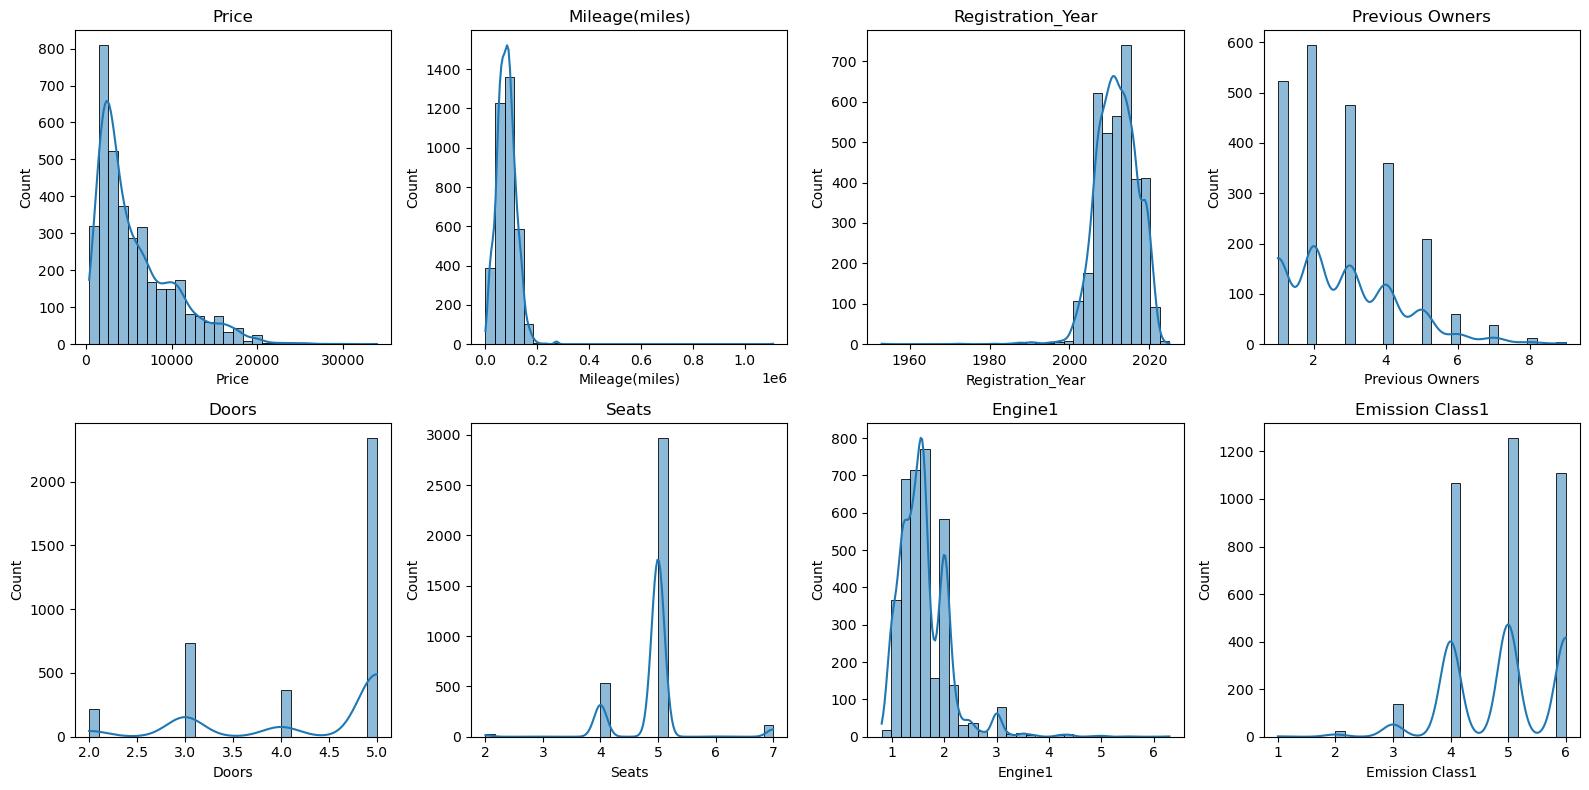

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df3,
        x=col,
        bins=30,
        ax=axes[i],
        kde=True
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

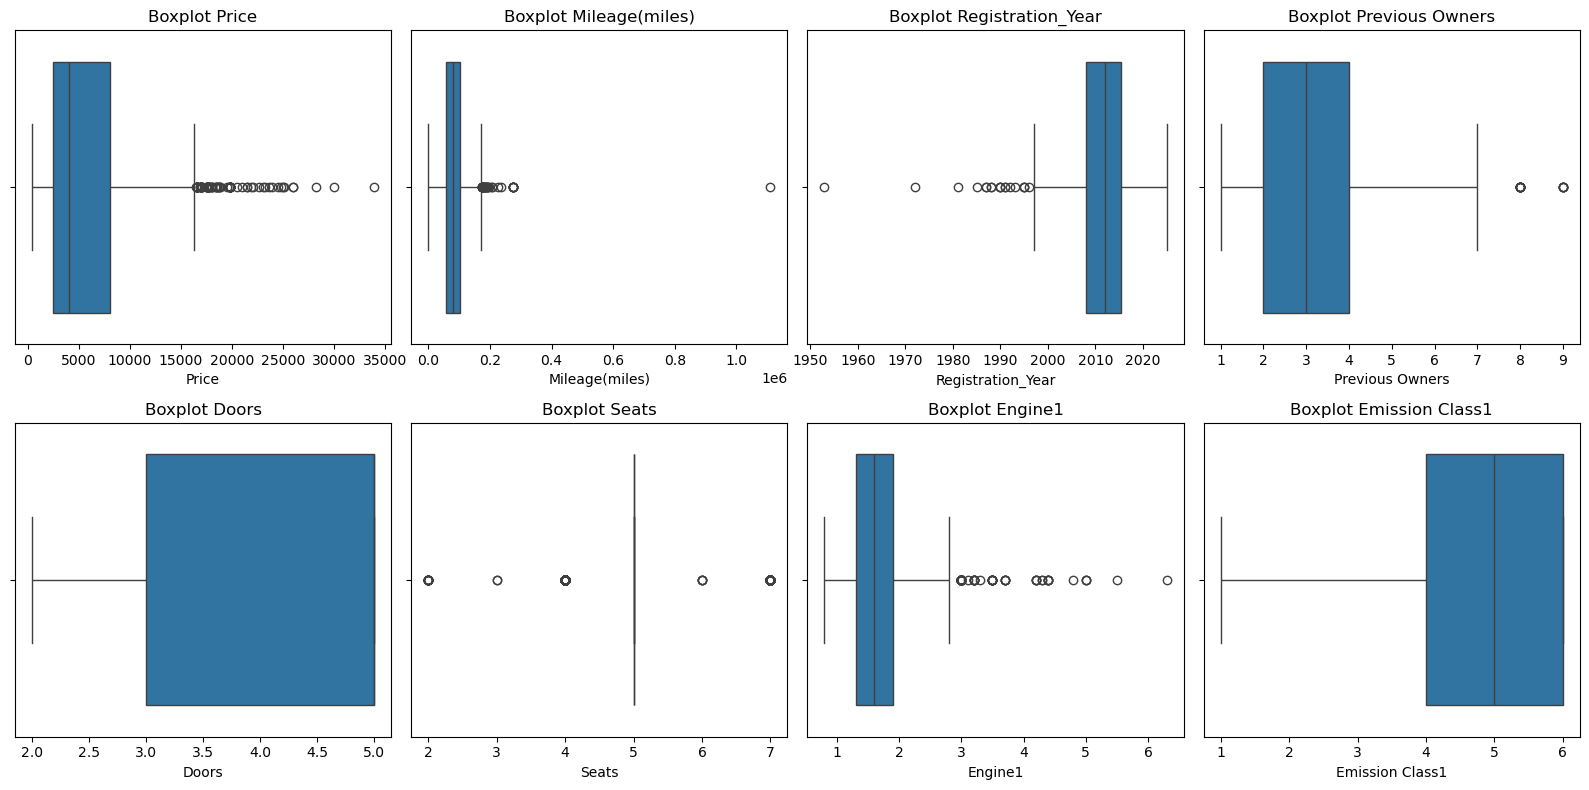

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df3,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

In [74]:
df3.isnull().mean()

title_x              0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Previous Owners      0.383465
Fuel type            0.000000
Body type            0.000000
Gearbox              0.000000
Doors                0.004079
Seats                0.006799
Service history      0.000000
title_first          0.000000
country              0.000000
Engine1              0.009519
Emission Class1      0.020941
dtype: float64

### 결측치가 6개 이상인 행 삭제
(타입변경한 Engine1,Emission Class1 포함)

In [69]:
#df3.isna().sum(axis=1).unique()
df3[df3.isna().sum(axis=1) >= 6]


df3 = df3[df3.isna().sum(axis=1) < 6]
df3.count()

title_x              3677
Price                3677
Mileage(miles)       3677
Registration_Year    3677
Previous Owners      2267
Fuel type            3677
Body type            3677
Engine               3642
Gearbox              3677
Doors                3662
Seats                3652
Emission Class       3600
Service history      3677
title_first          3677
title_y              3677
country              3677
Engine1              3642
Emission Class1      3600
dtype: int64

### 중복되는 컬럼 정리

In [72]:
drop_cols = [
    'Engine',
    'Emission Class',
    'title_y'
]

df3 = df3.drop(columns=drop_cols)

In [79]:
df3 = df3.rename(columns={'title_x':'title'})
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3686
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3677 non-null   object 
 1   Price              3677 non-null   int64  
 2   Mileage(miles)     3677 non-null   int64  
 3   Registration_Year  3677 non-null   int64  
 4   Previous Owners    2267 non-null   float64
 5   Fuel type          3677 non-null   object 
 6   Body type          3677 non-null   object 
 7   Gearbox            3677 non-null   object 
 8   Doors              3662 non-null   float64
 9   Seats              3652 non-null   float64
 10  Service history    3677 non-null   object 
 11  title_first        3677 non-null   object 
 12  country            3677 non-null   object 
 13  Engine1            3642 non-null   float64
 14  Emission Class1    3600 non-null   float64
dtypes: float64(5), int64(3), object(7)
memory usage: 459.6+ KB


In [76]:
df3.groupby('Body type')['Doors'].mean()

Body type
Combi Van      4.000000
Convertible    2.009259
Coupe          2.213235
Estate         5.000000
Hatchback      4.379356
MPV            5.000000
Minibus             NaN
Pickup         4.333333
SUV            4.986985
Saloon         3.994505
Name: Doors, dtype: float64

## 이변량 분석

In [83]:


num_cols = [col for col in num_cols if col != 'Price']
num_cols

['Mileage(miles)',
 'Registration_Year',
 'Previous Owners',
 'Doors',
 'Seats',
 'Engine1',
 'Emission Class1']

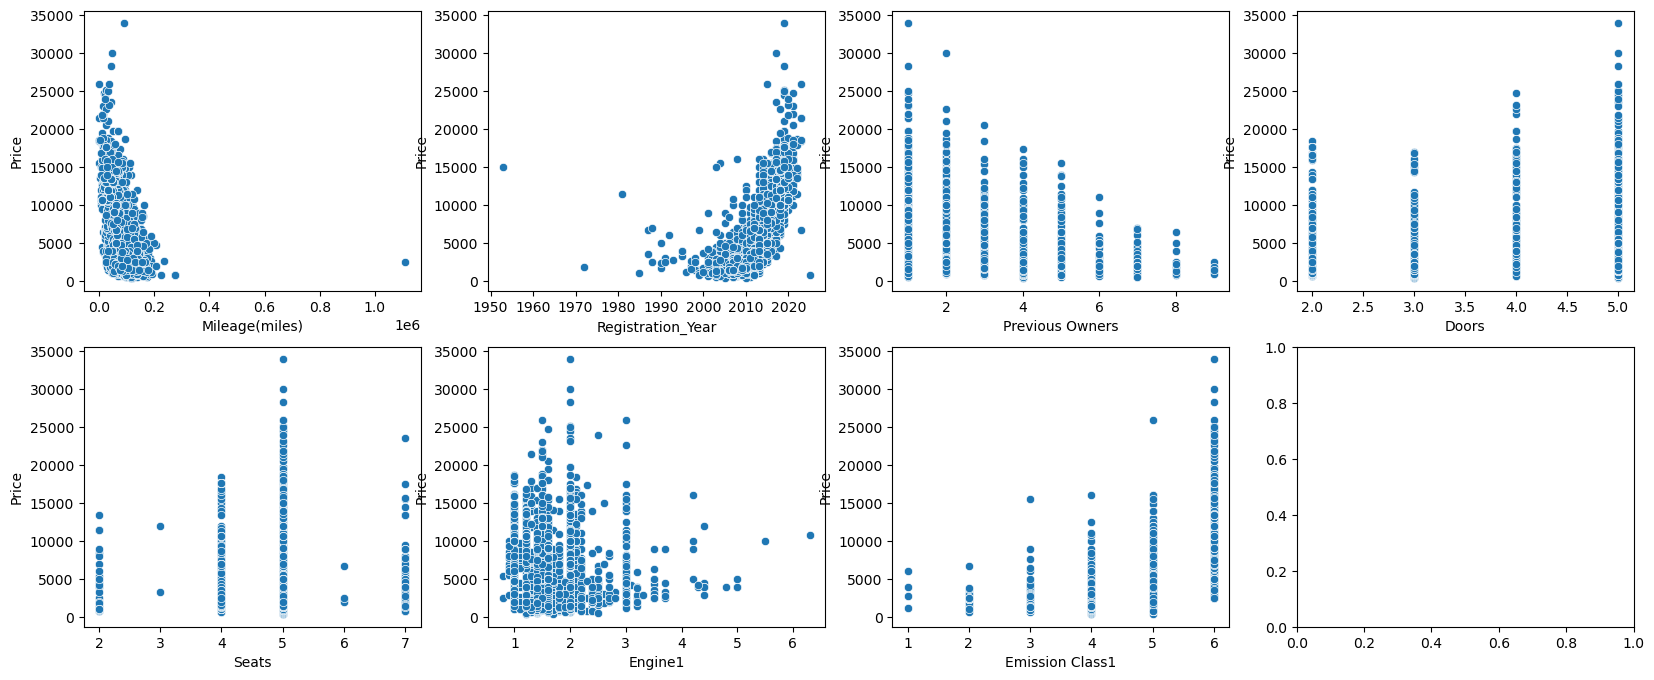

In [ ]:

fig, axes = plt.subplots(2,4, figsize=(20,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(
        data=df3,
        x=col,
        y='Price',
        ax=axes[i]
        )
    
    plt.legend
    plt.tight_layout
    plt.show



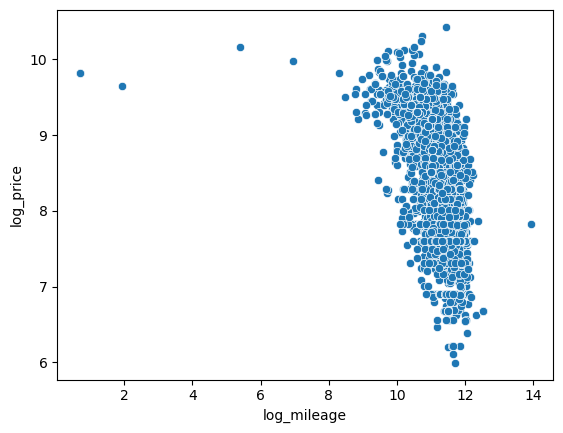

In [95]:
df3['log_mileage'] = np.log1p(df3['Mileage(miles)'])
df3["log_price"] = np.log1p(df3['Price'])


sns.scatterplot(data = df3, x="log_mileage", y="log_price")
plt.show()

주행거리가 길다고 무조건 가격이 저렴한 것도 아닌 것 같음
emission class 배출가스 등급이 높을수록 가격이 높음
등록년도가 최신일수록 가격이 높음
이전 소유주가 적을수록 가격이 높음 / 결측치 문제가 있음

previous Owner값도 결측치가 많은데.. 정말 이전 소유자가 없는 건지 아니면 정보를 모르는건지
결측치를 어떻게해야할지 모르겠음..
-> 38% 이정도 결측치의 경우 보통 컬럼을 날린다고 하여 drop 결정

In [96]:
df3 = df3.drop(columns=['Previous Owners'])
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3686
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3677 non-null   object 
 1   Price              3677 non-null   int64  
 2   Mileage(miles)     3677 non-null   int64  
 3   Registration_Year  3677 non-null   int64  
 4   Fuel type          3677 non-null   object 
 5   Body type          3677 non-null   object 
 6   Gearbox            3677 non-null   object 
 7   Doors              3662 non-null   float64
 8   Seats              3652 non-null   float64
 9   Service history    3677 non-null   object 
 10  title_first        3677 non-null   object 
 11  country            3677 non-null   object 
 12  Engine1            3642 non-null   float64
 13  Emission Class1    3600 non-null   float64
 14  log_mileage        3677 non-null   float64
 15  log_price          3677 non-null   float64
dtypes: float64(6), int64(3), obje

In [97]:
df3.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Fuel type            0.000000
Body type            0.000000
Gearbox              0.000000
Doors                0.004079
Seats                0.006799
Service history      0.000000
title_first          0.000000
country              0.000000
Engine1              0.009519
Emission Class1      0.020941
log_mileage          0.000000
log_price            0.000000
dtype: float64

doors 결측치를 고민하다보니
body type과 상관관계가 있을 것 같아서 확인해보기로 함
각각 데이터가 범주형, 범주형이라 카이제곱 검정을 진행하기로 함

### crosstab, 카이검정제곱
귀무가설 : body type과 doors는 연관이 없다.
독립가설 : body type과 doors는 연관이 있다.


Doors        2.0  3.0  4.0   5.0
Body type                       
Combi Van      0    1    0     1
Convertible  107    1    0     0
Coupe        108   27    1     0
Estate         0    0    0   170
Hatchback      0  703    1  1563
MPV            0    0    0   151
Pickup         0    0    2     1
SUV            0    3    0   458
Saloon         1    0  363     0


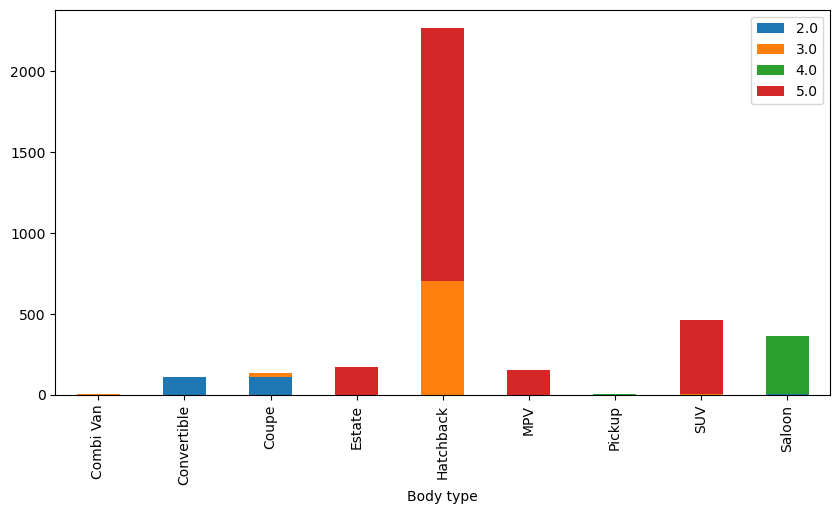

In [109]:
table = pd.crosstab(
    df3['Body type'],
    df3['Doors']
    )

print(table)

table.plot(
    kind = 'bar',
    stacked = True,
    figsize=(10,5)

)


plt.legend()
plt.show()


### 바디타입, 도어 상관관계 확인을 위한 카이제곱 검정

In [110]:
chi2, p, dof, expected = chi2_contingency(table)
p

np.float64(0.0)

처음에 crosstab에서 
normalize='index'를 사용한 결과값으로 카이제곱 검정을 실행했더니
p값이 0.8이 나옴

좀 이상해서 확인해보니
normalize로 계산하면 확률이고 관측 빈도가 아니여서 완전 다른 값이 나온다고함. 주의 필요


p값이 0.0으로 바디타입과 도어에는 통계적으로 유의미한 연관이 있음을 알 수 있었다.
이를 통해 door의 결측치를 body type의 최빈값으로 채우기로 결정함

In [115]:
df3.groupby('Body type')['Doors'].apply(lambda x : x.isna().all())
df3[df3['Body type'] == 'Minibus']


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Gearbox,Doors,Seats,Service history,title_first,country,Engine1,Emission Class1,log_mileage,log_price
957,NISSAN ELGRAND,4200,96000,2017,Petrol,Minibus,Automatic,NaN,7.0,Unknown,NISSAN,Japan,2.0,NaN,11.472114,8.343078


전체에서 미니버스인게 1개 있는데, door값이 결측치임. 데이터가 1개라 통계적 추정이 불가하여 해당 행 제거


In [118]:
df3 = df3[df3['Body type'] != 'Minibus']

df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3676 entries, 0 to 3686
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3676 non-null   object 
 1   Price              3676 non-null   int64  
 2   Mileage(miles)     3676 non-null   int64  
 3   Registration_Year  3676 non-null   int64  
 4   Fuel type          3676 non-null   object 
 5   Body type          3676 non-null   object 
 6   Gearbox            3676 non-null   object 
 7   Doors              3662 non-null   float64
 8   Seats              3651 non-null   float64
 9   Service history    3676 non-null   object 
 10  title_first        3676 non-null   object 
 11  country            3676 non-null   object 
 12  Engine1            3641 non-null   float64
 13  Emission Class1    3600 non-null   float64
 14  log_mileage        3676 non-null   float64
 15  log_price          3676 non-null   float64
dtypes: float64(6), int64(3), obje

In [119]:
df3['Doors'] = df3.groupby('Body type')['Doors'].transform(lambda x: x.fillna(x.mode()[0]))

In [120]:
df3.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Fuel type            0.000000
Body type            0.000000
Gearbox              0.000000
Doors                0.000000
Seats                0.006801
Service history      0.000000
title_first          0.000000
country              0.000000
Engine1              0.009521
Emission Class1      0.020675
log_mileage          0.000000
log_price            0.000000
dtype: float64

### seat 결측치 처리
seat 변수 분포를 확인해보니, 대부분 5라라서
최빈값으로 결측치 처리하기로함


In [122]:
df3['Seats'] = df3['Seats'].fillna(df3['Seats'].mode()[0])
df3.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Fuel type            0.000000
Body type            0.000000
Gearbox              0.000000
Doors                0.000000
Seats                0.000000
Service history      0.000000
title_first          0.000000
country              0.000000
Engine1              0.009521
Emission Class1      0.020675
log_mileage          0.000000
log_price            0.000000
dtype: float64

## 다변량 분석

                      Price  Mileage(miles)  Registration_Year     Doors  \
Price              1.000000       -0.500596           0.723844  0.110109   
Mileage(miles)    -0.500596        1.000000          -0.412345 -0.036430   
Registration_Year  0.723844       -0.412345           1.000000  0.223367   
Doors              0.110109       -0.036430           0.223367  1.000000   
Seats             -0.027127        0.094829           0.030345  0.493958   
Engine1           -0.022616        0.331677          -0.290745 -0.065214   
Emission Class1    0.697992       -0.378377           0.920095  0.181788   
log_mileage       -0.557959        0.787661          -0.434865 -0.070161   
log_price          0.923271       -0.521759           0.748311  0.109048   

                      Seats   Engine1  Emission Class1  log_mileage  log_price  
Price             -0.027127 -0.022616         0.697992    -0.557959   0.923271  
Mileage(miles)     0.094829  0.331677        -0.378377     0.787661  -0.52175

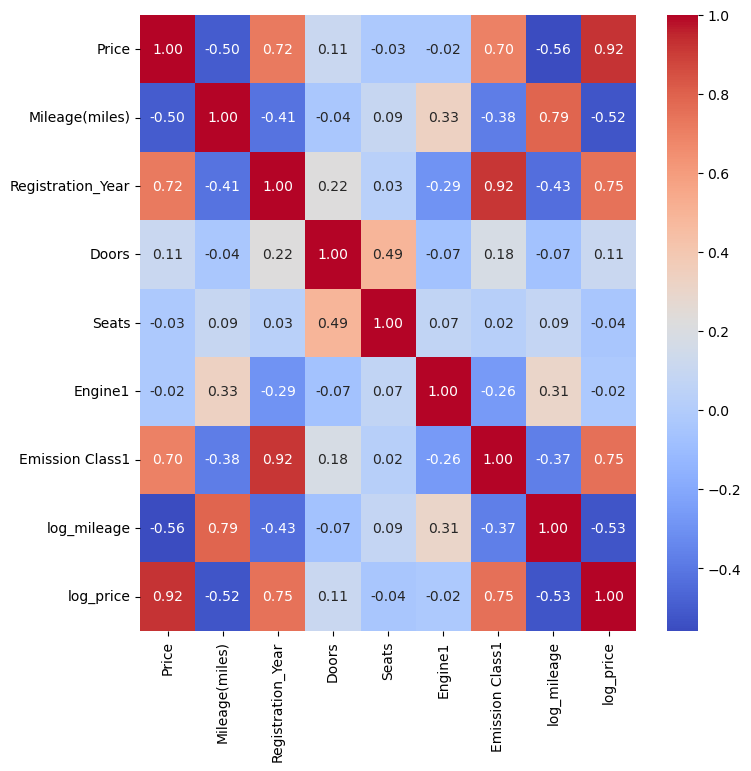

In [130]:
corr = df3.select_dtypes(include = 'number').corr()
print(corr)

plt.figure(figsize=(8,8))
sns.heatmap(
    corr,
    annot=True,
    fmt = '.2f',
    cmap = 'coolwarm'

)

plt.show()

emission class - registration year 0.92
emission class - price 0.7



emission class - registration year 0.92 상관관계 있음


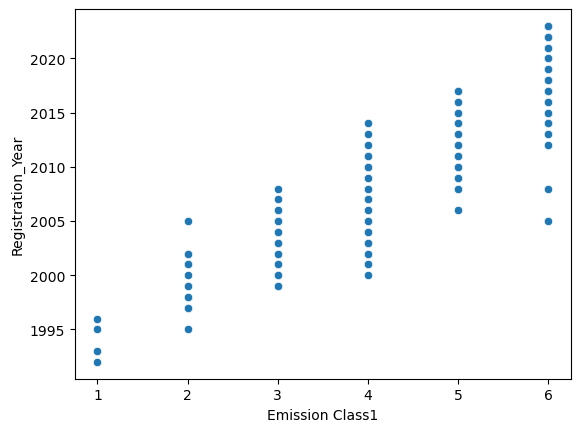

In [133]:
sns.scatterplot(
    data = df3,
    x = 'Emission Class1',
    y='Registration_Year'
)

plt.show()

두값이 통계적으로 유의미한지 보기위해
범주형 - 연속형 변수 두값의 관계를 spearman 상관계수 검정을 진행함

귀무가설 : emission class와 registration year 값은 연관이 없다
독립가설 : emission class와 registration year 값은 연관이 있다

In [137]:
subset = df3[["Emission Class1", "Registration_Year"]].dropna()

rho, p_value = spearmanr(
    subset["Emission Class1"],
    subset["Registration_Year"]
)

print(f"spearman rho : {rho}, p-value : {p_value}")

spearman rho : 0.933159754751087, p-value : 0.0


p값이 0.5 이하이고 spearman 상관계수 0.93으로 강한 양의 단조 관계
귀무가설 기각

registration year값을 통해 emission class 결측치를 채우기로 함

In [ ]:
df3.groupby("Registration_Year")["Emission Class1"] .apply(lambda x: x.isna().all())
df3['Registration_Year'].value_counts()

df3.groupby("Registration_Year")["Emission Class1"] \
   .agg(
       total="size",
       missing=lambda x: x.isna().sum()
   )

,total,missing
Registration_Year,,
1953,1,1
1972,1,1
1981,1,1
1985,1,1
1987,2,2
1988,2,2
1990,3,3
1991,2,2
1992,1,0


	total	missing
Registration_Year		
1953	1	1
1972	1	1
1981	1	1
1985	1	1
1987	2	2
1988	2	2
1990	3	3
1991	2	2


1953~1991년도에는 emission class 값이 없음
저 시기에는 기준이 없었을거라 추측됨
최저값 1로 결측치를 고민했는데
0을 추가해서 emission class 기준 이전 값으로 구분하기로 함

In [144]:
df3['Emission Class1'].unique()

df3.loc[
    df3['Emission Class1'].isna() & (df3['Registration_Year'] < 1992),
    'Emission Class1'
] = 0


2025년도 데이터는 1개인데, 그값이 결측치라
그래프와 spearman 상관계수 검정을 통해 emission class1 값 6으로 추측해서 결측치 채움

In [154]:
df3.loc[
    df3['Emission Class1'].isna() & (df3['Registration_Year'] == 2025),
    'Emission Class1'
] = 6

In [155]:
df3.groupby("Registration_Year")["Emission Class1"] \
   .agg(
       total="size",
       missing=lambda x: x.isna().sum()
   )

#df3[df3['Registration_Year'] == 2025]

,total,missing
Registration_Year,,
1953,1,0
1972,1,0
1981,1,0
1985,1,0
1987,2,0
1988,2,0
1990,3,0
1991,2,0
1992,1,0


년도별 emission class값을 통해 최빈값을 채우려했는데
특정년도 값이 모두 결측치면 아래 함수가 에러가 나서
1953~1991 , 2025 결측치를 채우고 나머지는 아래 함수로 결측치 처리

In [156]:
df3['Emission Class1'] = df3.groupby('Registration_Year')['Emission Class1'] \
        .transform(lambda x : x.fillna(x.mode()[0]))

In [162]:
df3.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Fuel type            0.000000
Body type            0.000000
Gearbox              0.000000
Doors                0.000000
Seats                0.000000
Service history      0.000000
title_first          0.000000
country              0.000000
Engine1              0.009521
Emission Class1      0.000000
log_mileage          0.000000
log_price            0.000000
dtype: float64

마지막 엔진..엔진은 숫자형 변수에서는 크게 상관관계 있는걸 못찾음
차종류?에 따라 비슷할 수도 있을 것 같아서
title 브랜드+모델값중 모델값을 분리해서 확인해보기로함


In [170]:
df3['model'] = df3['title'].str.strip().str.split().str[1:].str.join(" ")

In [ ]:
df3.head(20)
df3['model'].value_counts()


df3.groubpy('model')['Engine1'].

model
CORSA                  223
FOCUS                  162
ASTRA                  155
FIESTA                 128
3 SERIES               118
                      ... 
FABIA DIESEL ESTATE      1
VENGA                    1
DS3 CABRIO               1
MARTINA                  1
PRELUDE                  1
Name: count, Length: 450, dtype: int64

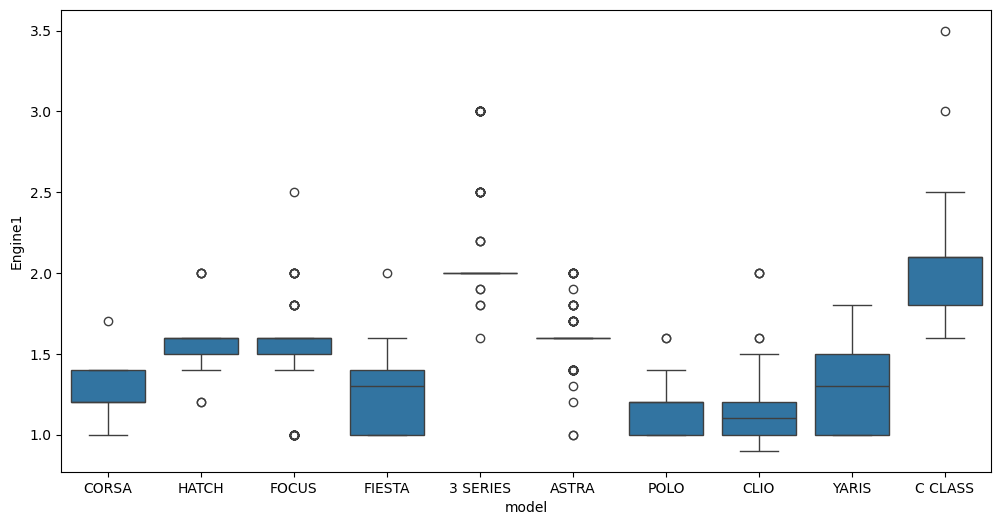

Engine1
1.6    736
2.0    552
1.2    521
1.4    421
1.0    326
1.5    294
1.3    170
1.8    158
3.0     79
2.2     75
2.1     63
1.1     39
1.7     35
2.5     33
1.9     31
2.4     28
0.9     15
2.7     11
3.5     10
3.2      7
3.7      5
4.4      5
2.3      4
2.6      4
4.2      4
5.0      3
2.8      3
0.8      2
4.3      2
5.5      1
4.8      1
3.1      1
3.3      1
6.3      1
Name: count, dtype: int64

In [175]:
top_models = df3["model"].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df3[df3["model"].isin(top_models)],
    x="model",
    y="Engine1"
)

plt.show()


df3['Engine1'].value_counts()

모델별 엔진 중앙값으로 채우기로 결정

In [179]:
df3['Engine1'] = (df3.groupby('model')['Engine1']
       .transform(lambda x: x.fillna(x.median()) if not x.dropna().empty else x)
)

남은 결측치 32개는 브랜드별 엔진의 중앙값으로 채움
title_first : 브랜드

In [182]:
df3['Engine1'] = (df3.groupby('title_first')['Engine1']
       .transform(lambda x: x.fillna(x.median()) if not x.dropna().empty else x)
)

나머지 1개 엔진 전체 중앙값으로 채움

In [187]:
df3['Engine1'] = df3['Engine1'].fillna(df3['Engine1'].median())

In [188]:
df3.isna().sum()

title                 0
Price                 0
Mileage(miles)        0
Registration_Year     0
Fuel type             0
Body type             0
Gearbox               0
Doors                 0
Seats                 0
Service history       0
title_first           0
country               0
Engine1               0
Emission Class1       0
log_mileage           0
log_price             0
model                 0
Engine               32
dtype: int64

# scaler

In [189]:
num_cols



['Mileage(miles)',
 'Registration_Year',
 'Doors',
 'Seats',
 'Engine1',
 'Emission Class1']

In [193]:
scaler = StandardScaler()
df3_scaled = df3.copy()

df3_scaled[num_cols] = scaler.fit_transform(df3_scaled[num_cols])

df3_scaled[num_cols].describe()

,Mileage(miles),Registration_Year,Doors,Seats,Engine1,Emission Class1
count,3.676000e+03,3.676000e+03,3.676000e+03,3.676000e+03,3.676000e+03,3.676000e+03
mean,-4.639017e-17,1.561802e-14,2.899385e-16,6.948861e-16,-1.700973e-16,1.237071e-16
std,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00
min,-2.062090e+00,-1.157522e+01,-2.350202e+00,-5.052177e+00,-1.662101e+00,-5.120233e+00
25%,-6.170256e-01,-7.559769e-01,-1.337621e+00,1.734287e-01,-6.298517e-01,-9.329189e-01
50%,-3.334973e-02,3.087695e-02,6.875416e-01,1.734287e-01,-1.050221e-02,1.139095e-01
75%,5.499204e-01,8.177308e-01,6.875416e-01,1.734287e-01,6.088473e-01,1.160738e+00
max,2.608954e+01,2.588152e+00,6.875416e-01,3.657166e+00,9.692640e+00,1.160738e+00


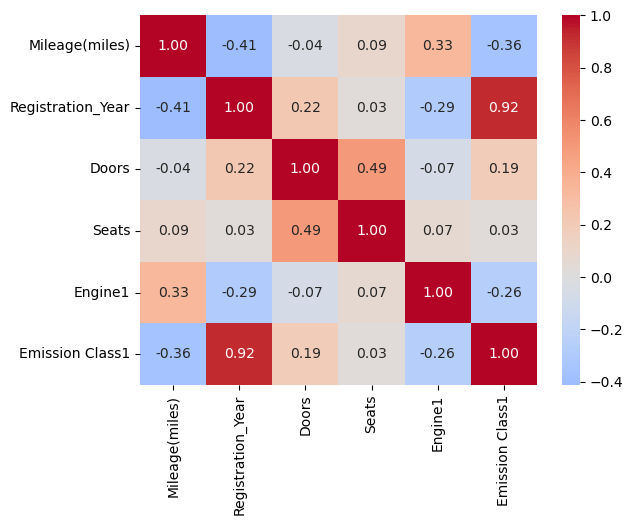

In [197]:
sns.heatmap(df3_scaled[num_cols].corr(), cmap='coolwarm', fmt = '.2f', annot=True, center=0)
plt.show()

In [ ]:

pca_70 = PCA(n_components=0.7)
X_pca_70 = pca_70.fit_transform(df3_scaled[num_cols])




In [200]:
pca_70.n_components_

np.int64(3)

In [202]:
pca_70.explained_variance_ratio_
pca_70.explained_variance_ratio_.sum()

np.float64(0.8002492725592645)

In [203]:
loadings_70 = pd.DataFrame(
    pca_70.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(pca_70.n_components_)]
)

loadings_70

,PC1,PC2,PC3
Mileage(miles),-0.397323,0.239170,0.342608
Registration_Year,0.593280,-0.013580,0.337644
Doors,0.215745,0.639797,-0.185342
Seats,0.055019,0.703959,-0.136803
Engine1,-0.328734,0.193415,0.746993
Emission Class1,0.576640,-0.017511,0.396927


PC1 : 최신 연식, 높은 배출등급, 적은 주행거리
PC2 : 많은 좌석, 많은 문
PC3 : 엔진 크기

가설 : 연식이 최신일수록 중고차 가격은 높을 것이다
가설 : 배출등급이 높을수록 중고차 가격이 높을 것이다
가설 : 차량의 주행거리가 짧을수록 가격이 높을 것이다